# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

### Importing the dataset

In [2]:
dataset = pd.read_csv("./../../../data/raw/Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [3]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Replace missing data

In [5]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

A feedforward neural network is constructed with:

*   Two hidden layers (both 6 neurons) using ReLU activation function.
*   One output layer with Sigmoid activation function for binary classification.

ReLU is used to introduce non-linearity, while Sigmoid outputs probabilities between 0 and 1.

### Initializing the ANN

In [8]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [9]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

c:\Users\Kazem\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Adding the second hidden layer

In [10]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [11]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

## **Training the ANN**


### Compiling the ANN
The model is compiled using:


*   **Adam optimizer** with learning rate 0.001 for efficient gradient updates.
*   **Binary Crossentropy loss**, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.








In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint
**ModelCheckpoint** saves the best-performing model during training.
These techniques improve model generalization and reproducibility.

In [13]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Training the ANN on the Training set

The model is trained for up to 100 epochs with a batch size of 32.
A validation split is used to monitor generalization performance during training.

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7920 - auc: 0.5448 - loss: 0.5401 - precision: 0.4082 - recall: 0.0151 - val_accuracy: 0.7994 - val_auc: 0.6118 - val_loss: 0.4937 - val_precision: 1.0000 - val_recall: 0.0031
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7955 - auc: 0.6559 - loss: 0.4830 - precision: 0.6512 - recall: 0.0212 - val_accuracy: 0.8025 - val_auc: 0.7002 - val_loss: 0.4612 - val_precision: 0.6154 - val_recall: 0.0497
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8033 - auc: 0.7137 - loss: 0.4583 - precision: 0.6307 - recall: 0.1150 - val_accuracy: 0.8069 - val_auc: 0.7289 - val_loss: 0.4478 - val_precision: 0.5890 - val_recall: 0.1335
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8086 - auc: 0.7342 - loss: 0.4472 - precision: 0.6163 - recall: 0.1944 - val_accuracy: 0.8081 - val_auc: 0.7397 - val_loss: 0.4413 - val_precision: 0.6000 - val_recall: 0.1398
Epoch 5/100
200/200 ━━━━━━━━

### Performance Visualization - Training and Validation Curves

Loss and performance metrics are plotted over epochs.
These curves help diagnose:

*   Underfitting
*   Overfitting
*   Training stability

Visualization allows better understanding of model learning behavior.

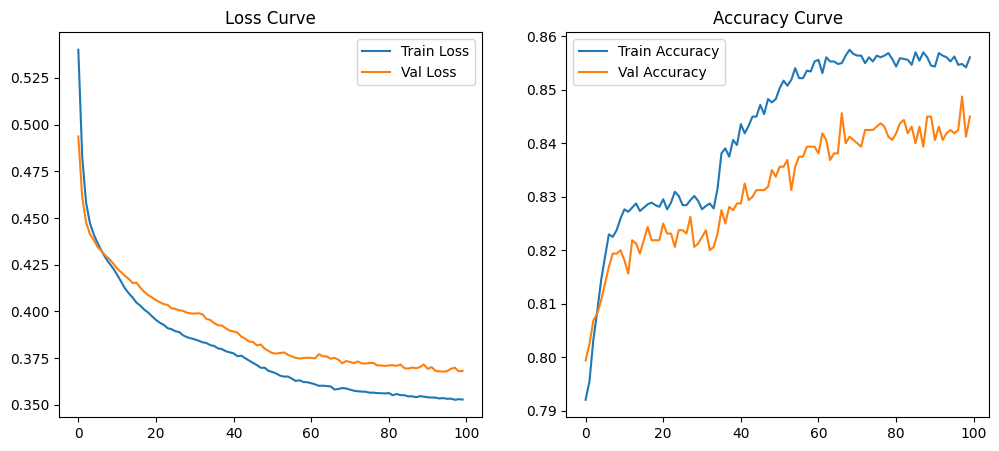

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

#### `Training Dynamics and Overfitting Analysis`

The training loss continuously decreases, while the validation loss stabilizes after an initial improvement. 
A small but consistent gap between training and validation curves indicates mild overfitting.

-> Issue :

The model continues improving on training data but stops improving on validation data.

-> Improvement Strategy :
- Introducing **Dropout** layers to reduce co-adaptation.
- Applying **L2 regularization** to penalize large weights.
- Using **EarlyStopping** to prevent unnecessary training beyond convergence.


## **Predicting and evaluating the model**

The trained model is evaluated on the test set.

### Confusion Matrix Analysis

The confusion matrix provides detailed insight into classification errors:

*   True Positives (TP)
*   True Negatives (TN)
*   False Positives (FP)
*   False Negatives (FN)

This analysis is critical in churn prediction, where missing churned customers (FN) may be costly.

In [ ]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

**Performance metrics** such as Accuracy, Precision, Recall, F1-score, and AUC are calculated to assess generalization ability.

In [17]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.3522191047668457, 0.8569999933242798, 0.718367338180542, 0.44783714413642883, 0.8426191806793213]

Classification Report:

              precision    recall  f1-score   support

           0     0.8764    0.9571    0.9149      1607
           1     0.7184    0.4478    0.5517       393

    accuracy                         0.8570      2000
   macro avg     0.7974    0.7025    0.7333      2000
weighted avg     0.8453    0.8570    0.8436      2000

ROC-AUC: 0.8425281568709415


### Plotting ROC Curve

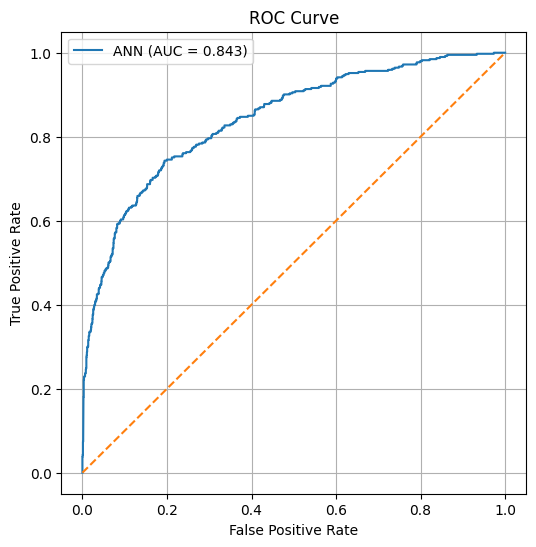

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

### `Class Imbalance and Minority Class Detection`

Although the model achieves good overall accuracy and ROC-AUC, recall for the churn class is relatively low (~0.43). 
This indicates that many churn customers are being misclassified as non-churn.

-> Issue :

High False Negatives due to class imbalance.

-> Improvement Strategy :
- Applying **class weights** during training.
- Using **oversampling techniques** (e.g., SMOTE).
- Adjusting the classification threshold below 0.5 to increase recall.

### `Model Capacity Limitation`

The current architecture contains two hidden layers with 6 neurons each. 
While sufficient for a baseline, this structure may limit representational power.

-> Issue :
Limited capacity to model complex feature interactions.

-> Improvement Strategy :
- Increasing number of neurons.
- Adding additional hidden layers.
- Experimenting with batch normalization for deeper architectures.


### `Training Stability and Generalization`

Validation accuracy plateaus after several epochs, indicating diminishing returns from continued training.

-> Issue :
Training beyond convergence may increase overfitting risk.

-> Improvement Strategy :
- Implementing **EarlyStopping** based on validation loss.
- Reducing number of epochs.
- Using **learning rate scheduling** to refine convergence.
